In [6]:
from langgraph.graph import StateGraph, START, END, add_messages
from langchain_aws import ChatBedrockConverse, BedrockEmbeddings
from langgraph.checkpoint.memory import InMemorySaver
from langgraph.prebuilt.tool_node import ToolNode
from langchain_community.tools import tool
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.messages import HumanMessage, SystemMessage, ToolMessage, AIMessage
from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.vectorstores import FAISS
from typing import TypedDict, Annotated, Literal, Optional, Tuple, List
import os
import operator
from rich import print
from langchain.document_loaders import PyPDFLoader

In [7]:
from langchain_aws import ChatBedrockConverse, BedrockEmbeddings

embedding_model = BedrockEmbeddings(model_id="cohere.embed-english-v3")

In [8]:
#embedding_model.embed_query("hi")

In [16]:
import os
os.getcwd()

'/home/labuser/A_RAG/Query Planner RAG'

In [17]:
# 1. Load and index PDF
loader = PyPDFLoader("Cyber Security Policy India.pdf")
docs = loader.load()
splitter = RecursiveCharacterTextSplitter(chunk_size=1000, 
                                          chunk_overlap=200,
                                          separators=["\n\n", "\n", ".", " ", ""])
chunks = splitter.split_documents(docs)

In [19]:
# 2. Load and index PDF
loader2 = PyPDFLoader("Cyber Security Policy UK.pdf")
docs2 = loader.load()
splitter2 = RecursiveCharacterTextSplitter(chunk_size=1000, 
                                          chunk_overlap=200,
                                          separators=["\n\n", "\n", ".", " ", ""])
chunks2 = splitter2.split_documents(docs2)

In [51]:
# Using the previously stored vector db's 
FAISS_PATH = './Cyber Security Policy India'
if os.path.exists(FAISS_PATH):
    ind_db = FAISS.load_local(
        FAISS_PATH,
        embedding_model,
        allow_dangerous_deserialization=True
    )
    print("Loaded existing FAISS index")
else:
    ind_db = FAISS.from_documents(
        chunks,
        embedding_model,
    )
    ind_db.save_local(FAISS_PATH)
    print("Created and saved new FAISS index")


Loaded existing FAISS index

In [52]:
# Using the previously stored vector db's 
FAISS_PATH = './Cyber Security Policy UK'
if os.path.exists(FAISS_PATH):
    ind_db = FAISS.load_local(
        FAISS_PATH,
        embedding_model,
        allow_dangerous_deserialization=True
    )
    print("Loaded existing FAISS index")
else:
    ind_db = FAISS.from_documents(
        chunks2,
        embedding_model,
    )
    ind_db.save_local(FAISS_PATH)
    print("Created and saved new FAISS index")


Loaded existing FAISS index

In [53]:
@tool
def get_india_cyber_policy(query: str):
    """search for relevant documents and return a text context.
    Args:
    query(str): A natural language query related to india's cyber security policy"""
    retriever = ind_db.as_retriever(k=2)
    results = retriever.invoke(query)
    return "\n\n".join([d.page_content for d in results])
@tool
def get_uk_cyber_policy(query: str):
    """search for relevant documents and return a text context.
    Args:
    query(str): A natural language query related to UK's cyber security policy"""
    
    retriever = uk_db.as_retriever(k=2)
    results = retriever.invoke(query)
    return "\n\n".join([d.page_content for d in results])
tool_node = ToolNode([get_india_cyber_policy,get_uk_cyber_policy])


In [54]:
llm = ChatBedrockConverse(model_id = "cohere.command-r-plus-v1:0")
#llm.invoke("Hi").content


In [55]:
from pydantic import BaseModel, Field
class Plan(BaseModel):
    """Plan to follow"""
    steps: List[str] = Field(
        description="A list of actionable steps. e.g.,['step 1: ...','step 2: ...']"
    )


In [56]:
from langchain_core.output_parsers import JsonOutputParser
plan_parser = JsonOutputParser(pydantic_object=Plan)


In [57]:
class AgentState(TypedDict):
    user_input: str
    messages: Annotated[list[str],add_messages]
    plan: list[str]
    context: Annotated[list[str],operator.add]
    past_steps: Annotated[list[Tuple],operator.add]
    final_answer: str


In [58]:
def plannerAgent(state: AgentState)-> AgentState:
    user_input = state['user_input']
    prompt = ChatPromptTemplate.from_messages([
        ('system',"""You are a planner agent. Create a step-by-step plan to achieve the objective.
        Available tools: get_india_cyber_policy, get_uk_cyber_policy
        The executor Agent can perform 2 tasks: retrieval using these tools and generate final reponse.
        So generate at max 3 step plan only.
        {format_instructions}
        The last step should provide the final answer."""),
        ('placeholder',"{messages}")
    ])
    chain = prompt | llm | plan_parser
    response = chain.invoke({
        'messages': [("user",user_input)],
        "format_instructions": plan_parser.get_format_instructions()
    })
    print(f"[planner Agent] plan generated: {response['steps']}")
    return {
        "plan": response['steps']
    }


In [59]:
def executorAgent(state: AgentState)-> AgentState:
    plan = state['plan'][0]
    prompt = f"""
    For the following plan: 
    {plan}
    You are tasked with executing the step 1.
    You are an intelligent context retriever. You have access to the following tools: get_india_cyber_policy, get_uk_cyber_policy.def
    Before making the tool call, you have to reframe the query specific to that tool and pass it to the tool as argument.def
    Think and make the neccessary tool call.
    """
    llm_with_tools = llm.bind_tools([get_india_cyber_policy,get_uk_cyber_policy])
    response = llm_with_tools.invoke(prompt)
    print(f"""[Executor Agent] Tool calls requested: {len(response.tool_calls) if hasattr(response, "tool_calls") else 0}""")
    return {"messages": response}
   
def should_continue(state: AgentState)-> Literal["tools","finalize"]:
    """Determine if tool calls are needed."""
    last_message = state['messages'][-1]
    if hasattr(last_message, "tool_calls") and last_message.tool_calls:
        print("[Router] Routing to tools")
        return "tools"
    else:
        print("[Router] No tool calls, routing to finalize node")
        return "finalize"
        
def process_context(state: AgentState)-> AgentState:
    """Extract context from tool results."""
    task = state['plan'][0]
    messages = state['messages']
    context = ""
    past_steps = state.get("past_steps",[])
    for msg in reversed(messages):
        if hasattr(msg, "type") and msg.type == 'tool':
            context = msg.content
            break
    if not context:
        context = "No context retrieved from tools"
    print(f"[Process context] Extracted context (length: {len(context)} chars)")
    return {
        "context": [context],
        "past_steps":[(task,[context])]
    }


In [60]:
def replan(state: AgentState)-> AgentState:
    user_input = state['user_input']
    past_steps = state['past_steps']
    plan = state['plan']
    prompt = ChatPromptTemplate.from_messages([
        ('system',"""
        You are a planner agent.
        Your task is to re-plan based on initial plan and past executed steps data, and create a step-by-step plan to achieve the Objective.
        Available tools: get_india_cyber_policy, get_uk_cyber_policy
        The executor agent can perform 2 tasks: retrieval using those tools and generate final response.
        Your Objective was this:
        {user_input}
        Your original plan was this:
        {plan}
        You have currently done the following steps:
        {past_steps}
        Update your plan accordingly. If no more steps are needed and you can return to the user, then respond with that. Otherwise, fill out the plan
        Only add steps to the plan that still NEED to be done. Do not return previously done steps as part of the plan.
        {format_instructions}
        """),('user','generate the new plan using the given context')
    ])
    chain = prompt | llm | plan_parser
    response = chain.invoke({
        "user_input": user_input,
        "plan": plan,
        "past_steps":past_steps,
        "format_instructions": plan_parser.get_format_instructions()
    })
    print("[re-plan node] plan refined")
    print(response['steps'])
    return {
        "plan": response['steps']
    }
def router_node(state: AgentState)->AgentState:
    #  when only the final step is remaining in the plan
    if len(state['plan'])==1:
        print("[router node] plan contains only 1 step. Routing to finalize node")
        return "finalize"
    else: 
        return "executor"


In [61]:
def finalize(state: AgentState)-> AgentState:
    user_input = state['user_input']
    past_steps = state['past_steps']
    context = state.get('context',"")
    prompt = f"""
    Your task to answer the user query using the previous steps results and retieved context.
    user query: {user_input}
    past steps task and results: {past_steps}
    retrieved context: {context}
    Use this info and generate a concise answer, keep it short and clear.
    """
    response = llm.invoke(prompt).content
    print("Generating the final response")
    return {
        "final_answer": response,
        "messages": [response]
    }


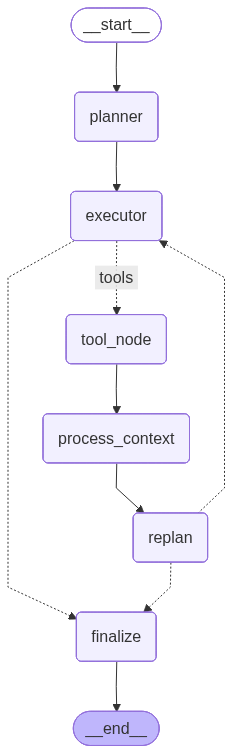

In [62]:
graph = StateGraph(AgentState)
graph.add_node("planner",plannerAgent)
graph.add_node("executor",executorAgent)
graph.add_node("tool_node",tool_node)
graph.add_node("process_context",process_context)
graph.add_node("replan",replan)
graph.add_node("finalize",finalize)
graph.add_edge(START,"planner")
graph.add_edge("planner","executor")
graph.add_conditional_edges(
    "executor",
    should_continue,
    {
        "tools":"tool_node",
        "finalize":"finalize"
    }
)
graph.add_edge("tool_node","process_context")
graph.add_edge("process_context","replan")
graph.add_conditional_edges(
    "replan",
    router_node,
    {
        "finalize":"finalize",
        "executor":"executor"
    }
)
graph.add_edge("finalize",END)
memory = InMemorySaver()
app = graph.compile(checkpointer=memory)
app


In [63]:
config = {"configurable":{"thread_id":"thread_1"}}
user_input = "What are the incident response guidelines in both india and uk policies?"
res = app.invoke({"messages":[HumanMessage(content=user_input)],"user_input":user_input},config = config)
print(res)


plan generated: ["Step 1: Retrieve India's cyber policy using the tool 'get_india_cyber_policy'.", "Step 2: 
Retrieve the UK's cyber policy using the tool 'get_uk_cyber_policy'.", "Step 3: Extract and compare incident 
response guidelines from both countries' cyber policies to identify common themes and differences."]

[Executor Agent] Tool calls requested: 1

[Router] Routing to tools

[Process context] Extracted context (length: 3845 chars)

plan refined

...

plan refined

[
    "Step 3: Extract and compare incident response guidelines from both countries' cyber policies to identify 
common themes and differences."
]

plan contains only 1 step. Routing to finalize node

Generating the final response

{
    'user_input': 'What are the incident response guidelines in both india and uk policies?',
    'messages': [
        HumanMessage(
            content='What are the incident response guidelines in both india and uk policies?',
            additional_kwargs={},
            response_metadata={},
            id='a252480c-fced-4adc-87af-440502145123'
        ),
        AIMessage(
            content=[
                {
                    'type': 'text',
                    'text': "I will use the get_india_cyber_policy tool to retrieve India's cyber security policy."
                },
                {
                    'type': 'tool_use',
                    'name': 'get_india_cyber_policy',
                    'input': {'query': "India's cyber security policy"},
                    'id': 'tooluse_ZJmPwsrjRL2fPXtQAgmZcw'
                }
            ],
            additional_kwargs={},
            response_metadata={
                'ResponseMetadata': {
                    'RequestId': '99563184-2ac9-464d-8305-2df02d2e4e7b',
                    'HTTPStatusCode': 200,
                    'HTTPHeaders': {
                        'date': 'Wed, 29 Oct 2025 11:39:06 GMT',
                        'content-type': 'application/json',
                        'content-length': '431',
                        'connection': 'keep-alive',
                        'x-amzn-requestid': '99563184-2ac9-464d-8305-2df02d2e4e7b'
                    },
                    'RetryAttempts': 0
                },
                'stopReason': 'tool_use',
                'metrics': {'latencyMs': [2134]},
                'model_name': 'cohere.command-r-plus-v1:0'
            },
            id='run--1002539b-848f-49e9-9b4b-db15faf57e7b-0',
            tool_calls=[
                {
                    'name': 'get_india_cyber_policy',
                    'args': {'query': "India's cyber security policy"},
                    'id': 'tooluse_ZJmPwsrjRL2fPXtQAgmZcw',
                    'type': 'tool_call'
                }
            ],
            usage_metadata={
                'input_tokens': 187,
                'output_tokens': 36,
                'total_tokens': 223,
                'input_token_details': {'cache_creation': 0, 'cache_read': 0}
            }
        ),
        ToolMessage(
            content='threats and minimize damage from cyber incidents through a combination of \ninstitutional 
structures, people, process, technology and cooperation. \n \nThe objective of this policy in broad terms is to 
create a secure cyberspace \necosystem and strengthen the regulatory framework at the national level. The 
\nNational Cyber Security policy se ts forth diverse objectives that range from \nenhancing the protection of 
India’s critical infrastructure, to assisting the investigation \nand prosecution of cybercrime, to developing 
500,000 skilled cyber security \nprofessionals over the next few years. To ac complish these objectives, the ibid 
policy \ndetails numerous action items for the Indian government, including:- \n \n(a) Designating a national 
agency to coordinate all cyber security matters. \n \n(b) Encouraging all private and public organizations to 
designate a Chief \nInformation Security Officer responsible for cyber security. \n(c) Developing a dynamic legal 
framework to address cyber security\n\n5  \nDTE OF STANDARDISATION \nDEPARTMENT OF DEFENCE PRODUCTION \nMINISTRY OF
DEFENCE \nCYBER SECURITY POLICY – 2019 \n1. Overview \n \n \nDue to rapid proliferation of information technology 
(IT) and its direct impact on \nthe functioning of an organization, IT and its functional ecosystems can no longer 
be \nviewed in isolation. Proliferation of IT has its flipside too; that of induced vulnerab ility \nto threat of 
cyber crimes. Hence it has become organizationally imperative to \nsafeguard the official cyber space from 
nefarious cyber crimes keeping the overall \nthreat in perspective \n \nOn July 2, 2013, the Indian government